# Rreprocessing - Xử lý dữ liệu

Sau khi đã phân tích sự tương quan giữa doanh thu `revenue` với các yếu tố khác trong toàn bộ tập dữ liệu, trong notebooks này chúng tôi sẽ xử lý chúng và thêm các đặc trưng mới dựa trên bảng gốc là `sales`. Điều này sẽ góp phần vào việc cải thiện mô hình sau này.

Cụ thể:
- Lấy toàn bộ dữ liệu có mức độ liên quan tới doanh thu cao
- Xử lý, làm sạch dữ liệu
- Tính toán, xây dựng các đặc trưng hữu ích
- Gộp toàn bộ dữ liệu vào một file và lưu lại

**Mục tiêu**: Xây dựng lại tập huấn luyện với nhiều đặc trưng để cải thiện mô hình dự đoán

Mục lục:
1. [Thiết lập và cài đặt](#1)
2. [Nhập dữ liệu](#2)
3. [Tổng hợp dữ liệu](#3)
4. [Tổng kết](#4)

<a id='1'></a>

## 1. Thiết lập và cài đặt

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import sys, os
sys.path.append(os.path.abspath('..'))
from src.get_data import get_connection

In [35]:
conn = get_connection()

[OKE] Kết nối thành công tới database tại C:\Users\YOGA\Desktop\MyProjects\datathon\github\vimchanhxa-datathon\data\database\datathon.duckdb


## 2. Nhập dữ liệu

In [36]:
# Bảng dữ liệu gốc: sales
sql = 'SELECT * FROM sales'
sales = conn.execute(sql).df()
sales.head()

,date,revenue,cogs
0,2012-07-04,5123547.94,3982991.19
1,2012-07-05,2751773.45,2150580.23
2,2012-07-06,3054029.42,2517632.84
3,2012-07-07,2667930.94,2108246.62
4,2012-07-08,2360851.90,1808622.79


In [37]:
# Bảng các mã giảm giá: promotions
sql = 'SELECT * FROM promotions'
promotions = conn.execute(sql).df()
promotions.head()

,promo_id,promo_name,promo_type,discount_value,start_date,end_date,applicable_category,promo_channel,stackable_flag,min_order_value
0,PROMO-0001,Spring Sale 2013,percentage,12.0,2013-03-18,2013-04-17,NaN,email,1,0.0
1,PROMO-0002,Mid-Year Sale 2013,percentage,18.0,2013-06-23,2013-07-22,NaN,online,0,0.0
2,PROMO-0003,Fall Launch 2013,percentage,10.0,2013-08-30,2013-10-02,NaN,email,0,0.0
3,PROMO-0004,Year-End Sale 2013,percentage,20.0,2013-11-18,2014-01-02,NaN,all_channels,0,50000.0
4,PROMO-0005,Urban Blowout 2013,fixed,50.0,2013-07-30,2013-09-02,Streetwear,online,0,150000.0


In [38]:
# Bảng đơn hàng: orders
sql = 'SELECT * FROM orders'
orders = conn.execute(sql).df()
orders.head()

,order_id,order_date,customer_id,zip,order_status,payment_method,device_type,order_source
0,1,2012-07-04,58578,1109,delivered,credit_card,desktop,paid_search
1,2,2012-07-04,58621,1330,returned,cod,mobile,paid_search
2,3,2012-07-04,58811,1473,delivered,credit_card,desktop,direct
3,4,2012-07-04,59453,2360,delivered,credit_card,desktop,referral
4,6,2012-07-06,57821,2886,delivered,paypal,mobile,email_campaign


In [39]:
# Bảng đơn hàng chi tiết: order_items
sql = 'SELECT * FROM order_items'
order_items = conn.execute(sql).df()
order_items.head()

,order_id,product_id,quantity,unit_price,discount_amount,promo_id,promo_id_2
0,1,2400,7,1138.22,0.0,NaN,NaN
1,2,609,7,10166.25,0.0,NaN,NaN
2,3,396,3,11220.33,0.0,NaN,NaN
3,4,635,5,10639.25,0.0,NaN,NaN
4,6,1935,1,1597.84,0.0,NaN,NaN


In [40]:
# Bảng thông tin thanh toán: payments
sql = 'SELECT * FROM payments'
payments = conn.execute(sql).df()
payments.head()

,order_id,payment_method,payment_value,installments
0,1,credit_card,7967.54,3
1,2,cod,71163.75,1
2,3,credit_card,33660.99,3
3,4,credit_card,53196.25,3
4,6,paypal,1597.84,1


In [41]:
# Bảng đánh giá: reviews
sql = 'SELECT * FROM reviews'
reviews = conn.execute(sql).df()
reviews.head()

,review_id,order_id,product_id,customer_id,review_date,rating,review_title
0,REV-0000001,1,2400,58578,2012-07-24,5,Highly recommend
1,REV-0000002,3,396,58811,2012-08-03,5,Very satisfied
2,REV-0000003,10,1431,49101,2012-07-23,5,Great quality
3,REV-0000005,16,1668,41028,2012-08-05,5,Great quality
4,REV-0000006,17,2352,42030,2012-07-17,4,Good overall


In [42]:
# Bảng tồn kho: inventory
sql = 'SELECT * FROM inventory'
inventory = conn.execute(sql).df()
inventory.head()

,snapshot_date,product_id,stock_on_hand,units_received,units_sold,stockout_days,days_of_supply,fill_rate,stockout_flag,overstock_flag,reorder_flag,sell_through_rate,product_name,category,segment,year,month
0,2022-10-31,1,3,1,1,2,90.0,0.933,1,0,0,0.250,DragonWear MA-01,Casual,All-weather,2022,10
1,2022-11-30,1,3,1,1,1,90.0,0.967,1,0,0,0.250,DragonWear MA-01,Casual,All-weather,2022,11
2,2022-12-31,1,3,1,1,1,90.0,0.967,1,0,0,0.250,DragonWear MA-01,Casual,All-weather,2022,12
3,2016-04-30,3,35,13,11,2,95.5,0.933,1,1,0,0.239,DragonWear MA-03,Casual,All-weather,2016,4
4,2016-05-31,3,36,11,10,1,108.0,0.967,1,1,0,0.217,DragonWear MA-03,Casual,All-weather,2016,5


In [43]:
# Bảng thông tin truy cập: web_traffic
sql = 'SELECT * FROM web_traffic'
web_traffic = conn.execute(sql).df()
web_traffic.head()

,date,sessions,unique_visitors,page_views,bounce_rate,avg_session_duration_sec,traffic_source
0,2013-01-01,9760,7253,39093,0.005,102.9,organic_search
1,2013-01-02,10456,8151,47611,0.004,120.5,organic_search
2,2013-01-03,10076,7458,36963,0.004,263.6,direct
3,2013-01-04,9973,8063,53078,0.006,151.8,direct
4,2013-01-05,10223,7882,36790,0.005,168.6,referral


## 3. Tổng hợp dữ liệu
Ở phần này, tôi sẽ tập hợp tất cả thông tin liên quan đến `revenue`

### 3.1 Orders

In [44]:
# 2. Merge hai bảng dựa trên order_id
# Chúng ta dùng 'inner' để đảm bảo chỉ lấy những đơn hàng có chi tiết sản phẩm
df_merged = pd.merge(orders, order_items, on='order_id', how='inner')

# 4. Tổng hợp dữ liệu theo Ngày (Daily Aggregation)
# Đây là bước quan trọng để đưa dữ liệu về dạng Time-series
df_daily_revenue = df_merged.groupby('order_date').agg(
    order_count=('order_id', 'nunique'),        # Số lượng đơn hàng trong ngày
    unique_customers=('customer_id', 'nunique'), # Số lượng khách hàng trong ngày
    total_quantity=('quantity', 'sum')          # Tổng số lượng sản phẩm bán ra
).reset_index()

# 5. Sắp xếp theo thứ tự thời gian
df_daily_revenue = df_daily_revenue.sort_values('order_date')

print("Dữ liệu sau khi merge và tổng hợp theo ngày:")
df_daily_revenue.head()

Dữ liệu sau khi merge và tổng hợp theo ngày:


,order_date,order_count,unique_customers,total_quantity
0,2012-07-04,162,161,777
1,2012-07-05,97,97,428
2,2012-07-06,93,93,441
3,2012-07-07,73,73,364
4,2012-07-08,88,87,394


In [45]:
df_daily_revenue.isnull().sum().sum()

np.int64(0)

In [46]:
df_final = pd.merge(
    sales, 
    df_daily_revenue, 
    left_on='date', 
    right_on='order_date', 
    how='left'
)

# 4. Loại bỏ cột 'order_date' thừa sau khi merge
df_final = df_final.drop(columns=['order_date'])

print("Đã hoàn tất merge dữ liệu từ đơn hàng vào bảng Sales chuẩn!")
print("Kiểm tra giá trị Nan:", df_final.isnull().sum().sum())
df_final.head()

Đã hoàn tất merge dữ liệu từ đơn hàng vào bảng Sales chuẩn!
Kiểm tra giá trị Nan: 0


,date,revenue,cogs,order_count,unique_customers,total_quantity
0,2012-07-04,5123547.94,3982991.19,162,161,777
1,2012-07-05,2751773.45,2150580.23,97,97,428
2,2012-07-06,3054029.42,2517632.84,93,93,441
3,2012-07-07,2667930.94,2108246.62,73,73,364
4,2012-07-08,2360851.90,1808622.79,88,87,394


### 3.2 Promotions

In [47]:
promotions.info()

<class 'pandas.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   promo_id             50 non-null     str           
 1   promo_name           50 non-null     str           
 2   promo_type           50 non-null     str           
 3   discount_value       50 non-null     float64       
 4   start_date           50 non-null     datetime64[us]
 5   end_date             50 non-null     datetime64[us]
 6   applicable_category  10 non-null     str           
 7   promo_channel        50 non-null     str           
 8   stackable_flag       50 non-null     int32         
 9   min_order_value      50 non-null     float64       
dtypes: datetime64[us](2), float64(2), int32(1), str(5)
memory usage: 3.8 KB


In [48]:
promotions.fillna('All', inplace=True).head()

,promo_id,promo_name,promo_type,discount_value,start_date,end_date,applicable_category,promo_channel,stackable_flag,min_order_value
0,PROMO-0001,Spring Sale 2013,percentage,12.0,2013-03-18,2013-04-17,All,email,1,0.0
1,PROMO-0002,Mid-Year Sale 2013,percentage,18.0,2013-06-23,2013-07-22,All,online,0,0.0
2,PROMO-0003,Fall Launch 2013,percentage,10.0,2013-08-30,2013-10-02,All,email,0,0.0
3,PROMO-0004,Year-End Sale 2013,percentage,20.0,2013-11-18,2014-01-02,All,all_channels,0,50000.0
4,PROMO-0005,Urban Blowout 2013,fixed,50.0,2013-07-30,2013-09-02,Streetwear,online,0,150000.0


In [49]:
promo_daily_list = []
for _, row in promotions.iterrows():
    # Tạo dải ngày chạy cho từng mã
    dates = pd.date_range(row['start_date'], row['end_date'], freq='D')
    
    temp_df = pd.DataFrame({'date': dates})
    
    # Tách biến động theo Tỷ lệ (%) và Số tiền cố định (fixed)
    temp_df['discount_pct'] = row['discount_value'] if row['promo_type'] == 'percentage' else 0
    temp_df['discount_fixed'] = row['discount_value'] if row['promo_type'] == 'fixed' else 0
    
    # Tách biến động theo quy mô: Áp dụng toàn sàn hay chỉ 1 ngành hàng nhất định
    temp_df['is_global_promo'] = 1 if row['applicable_category'] == 'All' else 0
    temp_df['is_specific_promo'] = 1 if row['applicable_category'] != 'All' else 0
    
    promo_daily_list.append(temp_df)

# Nối tất cả các ngày có khuyến mãi lại
df_promo_expanded = pd.concat(promo_daily_list)

# 4. Tổng hợp theo ngày (Để xử lý trường hợp 2 mã vô tình chồng lên nhau trong 1 ngày)
df_promo_clean = df_promo_expanded.groupby('date').agg(
    discount_pct=('discount_pct', 'sum'),
    discount_fixed=('discount_fixed', 'sum'),
    is_global_promo=('is_global_promo', 'max'),     # max để lấy 1 nếu có ít nhất 1 mã global
    is_specific_promo=('is_specific_promo', 'max')
).reset_index()

# 5. Merge vào bảng df_final (Bảng gốc đang chứa revenue)
df_final = pd.merge(df_final, df_promo_clean, on='date', how='left')

# 6. Fill NaN bằng 0 cho những ngày bình thường không có đợt Sale nào
cols_to_fill = ['discount_pct', 'discount_fixed', 'is_global_promo', 'is_specific_promo']
df_final[cols_to_fill] = df_final[cols_to_fill].fillna(0)

print("Đã merge thành công!")
df_final.tail()

Đã merge thành công!


,date,revenue,cogs,order_count,unique_customers,total_quantity,discount_pct,discount_fixed,is_global_promo,is_specific_promo
3828,2022-12-27,2100553.66,2184872.24,108,107,599,20.0,0.0,1.0,0.0
3829,2022-12-28,3448729.20,3513621.00,164,163,901,20.0,0.0,1.0,0.0
3830,2022-12-29,3083944.33,3170787.10,143,143,684,20.0,0.0,1.0,0.0
3831,2022-12-30,2884668.76,3022292.15,106,106,502,20.0,0.0,1.0,0.0
3832,2022-12-31,2383037.48,2279288.13,74,74,391,20.0,0.0,1.0,0.0


Theo như tìm hiểu và kiểm tra dữ liệu từ bảng `promotions`, chúng tôi nhận thấy là doanh nghiệp đang mở các sự kiện theo chu kỳ, và nó gần như không hề thay đổi qua các năm, có 2 mã giảm giá là ngoại lệ 2 năm mới có một lần và chỉ có một vài cột là có thay đổi nên sẽ không được sử dụng. Do đó, chúng tôi sẽ sử dụng mã giảm giá này nhưng lặp lại cho tương lai. Điều này giúp cho mô hình biết trước được tương lai và có thể dự đoán chính xác hơn

### 3.3 Reviews

In [50]:
reviews.info()

<class 'pandas.DataFrame'>
RangeIndex: 113551 entries, 0 to 113550
Data columns (total 7 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   review_id     113551 non-null  str           
 1   order_id      113551 non-null  int32         
 2   product_id    113551 non-null  int32         
 3   customer_id   113551 non-null  int32         
 4   review_date   113551 non-null  datetime64[us]
 5   rating        113551 non-null  int32         
 6   review_title  113551 non-null  str           
dtypes: datetime64[us](1), int32(4), str(2)
memory usage: 4.3 MB


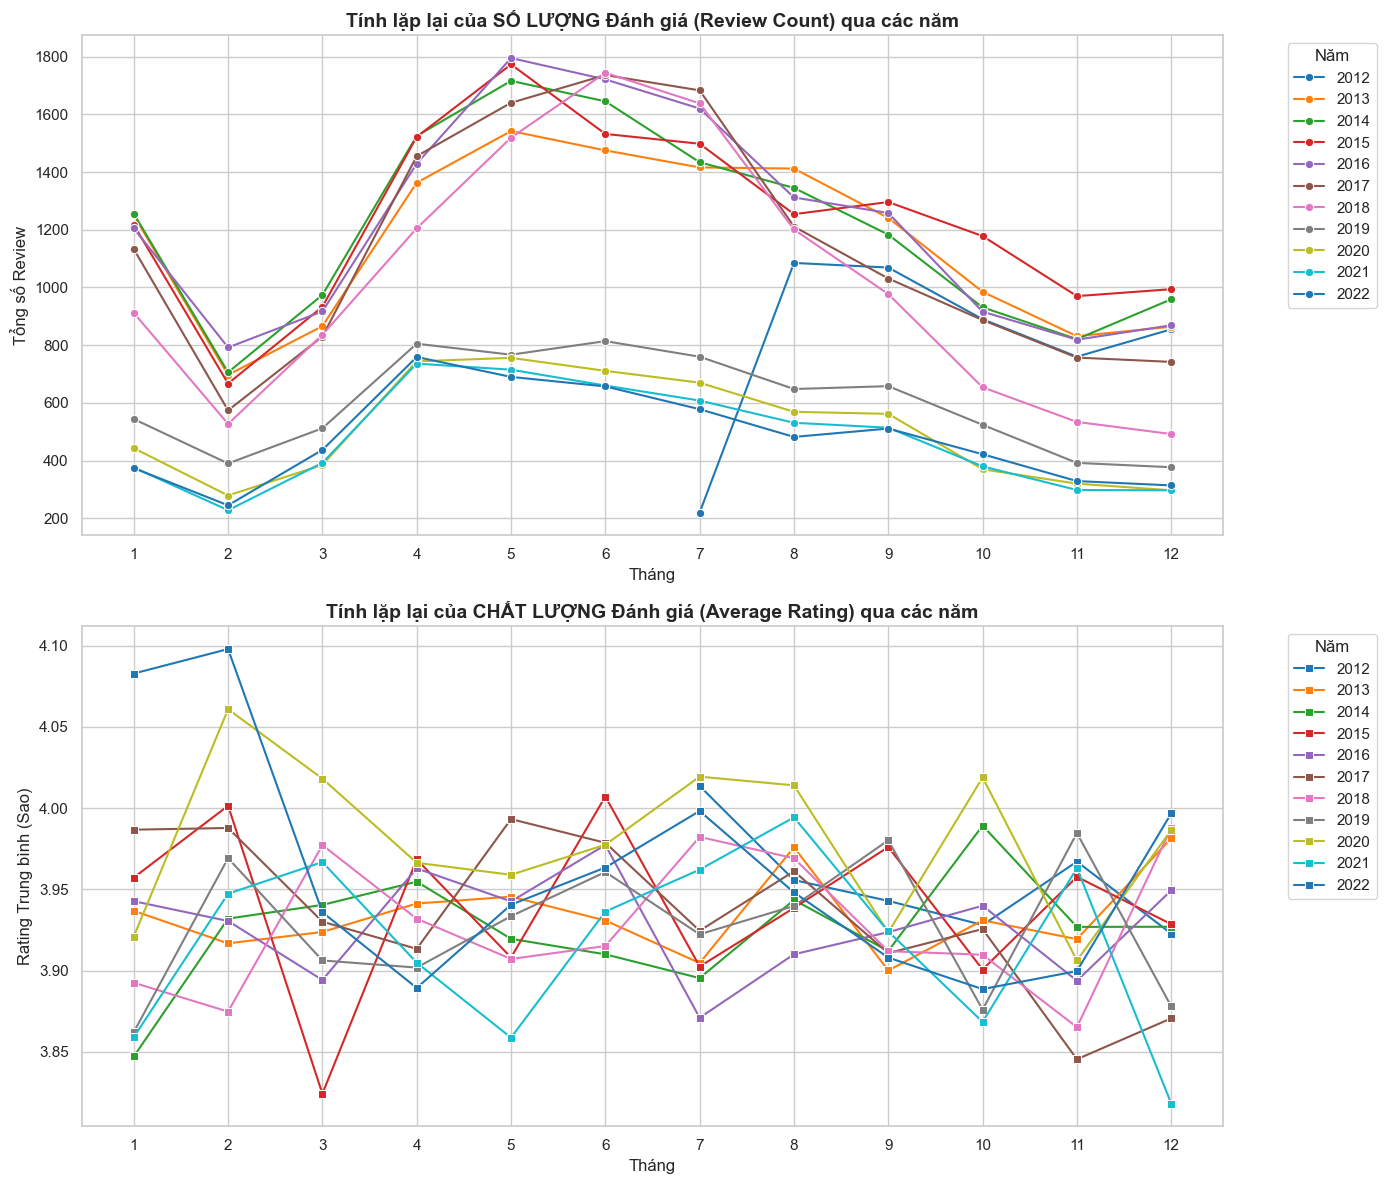

In [51]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Tiền xử lý dữ liệu (nếu chưa làm)
reviews['review_date'] = pd.to_datetime(reviews['review_date'])
reviews['year'] = reviews['review_date'].dt.year
reviews['month'] = reviews['review_date'].dt.month

# 2. Tổng hợp dữ liệu theo từng Năm và Tháng
monthly_stats = reviews.groupby(['year', 'month']).agg(
    review_count=('review_id', 'count'),
    avg_rating=('rating', 'mean')
).reset_index()

# Thiết lập style cho biểu đồ đẹp hơn
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(2, 1, figsize=(14, 12))

# ==========================================
# Biểu đồ 1: SỐ LƯỢNG ĐÁNH GIÁ TỪNG THÁNG
# ==========================================
sns.lineplot(
    data=monthly_stats, 
    x='month', 
    y='review_count', 
    hue='year', 
    palette='tab10', 
    marker='o', 
    ax=axes[0]
)
axes[0].set_title('Tính lặp lại của SỐ LƯỢNG Đánh giá (Review Count) qua các năm', fontsize=14, fontweight='bold')
axes[0].set_xticks(range(1, 13))
axes[0].set_xlabel('Tháng')
axes[0].set_ylabel('Tổng số Review')
axes[0].legend(title='Năm', bbox_to_anchor=(1.05, 1), loc='upper left')

# ==========================================
# Biểu đồ 2: ĐIỂM SỐ TRUNG BÌNH TỪNG THÁNG
# ==========================================
sns.lineplot(
    data=monthly_stats, 
    x='month', 
    y='avg_rating', 
    hue='year', 
    palette='tab10', 
    marker='s', 
    ax=axes[1]
)
axes[1].set_title('Tính lặp lại của CHẤT LƯỢNG Đánh giá (Average Rating) qua các năm', fontsize=14, fontweight='bold')
axes[1].set_xticks(range(1, 13))
axes[1].set_xlabel('Tháng')
axes[1].set_ylabel('Rating Trung bình (Sao)')
axes[1].legend(title='Năm', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

Mặc dù dữ liệu từ bảng `reviews` có thể cho ta thấy được với nhiều đánh giá tốt sẽ tăng lượt mua hàng, còn với đánh giá xấu thì sẽ làm giảm lượt mua hàng và doanh thu. Nhưng để dự đoán được cho 19 tháng sau thì bắt buộc dữ liệu phải có điểm đánh giá qua từng tháng trong các năm phải đồng bộ lên xuống với doanh thu, mà sau khi kiểm tra tính chu kỳ, cho việc đánh giá, chúng tôi nhận thấy rằng đây là **dữ liệu nhiễu ngẫu nhiên** và không thể cho vào mô hình tránh mô hình học loạn hơn.

### 3.4 Inventory

In [52]:
inventory.info()

<class 'pandas.DataFrame'>
RangeIndex: 60247 entries, 0 to 60246
Data columns (total 17 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   snapshot_date      60247 non-null  datetime64[us]
 1   product_id         60247 non-null  int32         
 2   stock_on_hand      60247 non-null  int32         
 3   units_received     60247 non-null  int32         
 4   units_sold         60247 non-null  int32         
 5   stockout_days      60247 non-null  int32         
 6   days_of_supply     60247 non-null  float64       
 7   fill_rate          60247 non-null  float64       
 8   stockout_flag      60247 non-null  int32         
 9   overstock_flag     60247 non-null  int32         
 10  reorder_flag       60247 non-null  int32         
 11  sell_through_rate  60247 non-null  float64       
 12  product_name       60247 non-null  str           
 13  category           60247 non-null  str           
 14  segment          

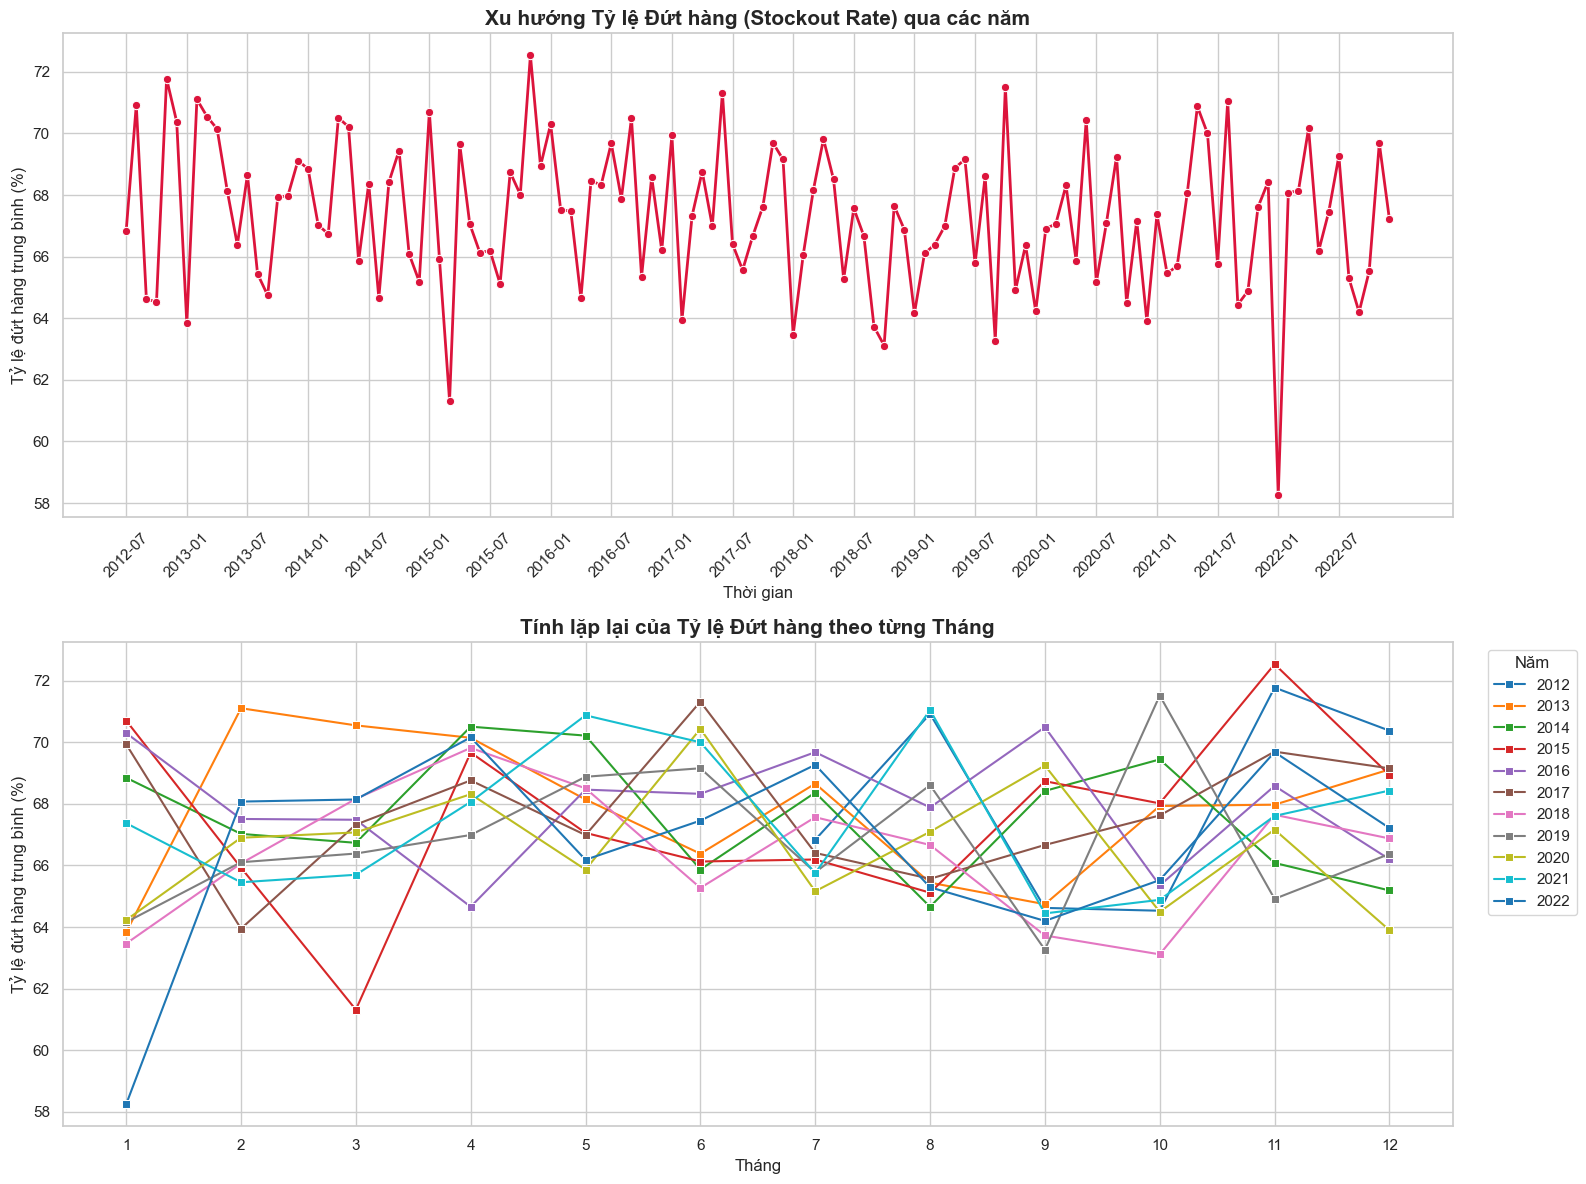

In [53]:
# 1. Đảm bảo định dạng thời gian
inventory['snapshot_date'] = pd.to_datetime(inventory['snapshot_date'])

# 2. Tính Tỷ lệ đứt hàng (Stockout Rate) theo từng ngày
daily_inv = inventory.groupby('snapshot_date').agg(
    total_items=('product_id', 'count'),
    out_of_stock=('stockout_flag', 'sum')
).reset_index()

# Tính % hết hàng
daily_inv['stockout_rate'] = (daily_inv['out_of_stock'] / daily_inv['total_items']) * 100

# Trích xuất Năm và Tháng để vẽ biểu đồ
daily_inv['year'] = daily_inv['snapshot_date'].dt.year
daily_inv['month'] = daily_inv['snapshot_date'].dt.month

# 3. Tính trung bình tháng để đường vẽ mượt mà hơn, tránh nhiễu hàng ngày
monthly_inv = daily_inv.groupby(['year', 'month'])['stockout_rate'].mean().reset_index()

# Tạo một cột time_period dạng string (VD: '2015-08') để trục X hiển thị liên tục
monthly_inv['time_period'] = monthly_inv['year'].astype(str) + '-' + monthly_inv['month'].astype(str).str.zfill(2)

# 4. Vẽ biểu đồ
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(2, 1, figsize=(16, 12))

# ==========================================
# Biểu đồ 1: XU HƯỚNG DÀI HẠN (MACRO TREND)
# ==========================================
sns.lineplot(
    data=monthly_inv, 
    x='time_period', 
    y='stockout_rate', 
    ax=axes[0], 
    color='crimson', 
    linewidth=2,
    marker='o'
)
axes[0].set_title('Xu hướng Tỷ lệ Đứt hàng (Stockout Rate) qua các năm', fontsize=15, fontweight='bold')
# Chỉ hiện 1 số tick trên trục X cho đỡ rối mắt (hiện mỗi 6 tháng)
axes[0].set_xticks(axes[0].get_xticks()[::6]) 
axes[0].tick_params(axis='x', rotation=45)
axes[0].set_ylabel('Tỷ lệ đứt hàng trung bình (%)')
axes[0].set_xlabel('Thời gian')

# ==========================================
# Biểu đồ 2: TÍNH MÙA VỤ (SEASONALITY)
# ==========================================
sns.lineplot(
    data=monthly_inv, 
    x='month', 
    y='stockout_rate', 
    hue='year', 
    palette='tab10', 
    marker='s', 
    ax=axes[1]
)
axes[1].set_title('Tính lặp lại của Tỷ lệ Đứt hàng theo từng Tháng', fontsize=15, fontweight='bold')
axes[1].set_xticks(range(1, 13))
axes[1].set_ylabel('Tỷ lệ đứt hàng trung bình (%)')
axes[1].set_xlabel('Tháng')
axes[1].legend(title='Năm', bbox_to_anchor=(1.02, 1), loc='upper left')

plt.tight_layout()
plt.show()

Dữ liệu từ bảng `inventory` cũng như `reviews` đều xảy như như một sự ngẫu nhiên, không có tính quy luật bởi nó đều bị tác động bởi nhiều thứ bên ngoài. Do đó dữ liệu từ bảng này cũng sẽ không được sử dụng cho mô hình

### 3.5 Web Traffic

In [54]:
web_traffic.info()

<class 'pandas.DataFrame'>
RangeIndex: 3652 entries, 0 to 3651
Data columns (total 7 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   date                      3652 non-null   datetime64[us]
 1   sessions                  3652 non-null   int32         
 2   unique_visitors           3652 non-null   int32         
 3   page_views                3652 non-null   int32         
 4   bounce_rate               3652 non-null   float64       
 5   avg_session_duration_sec  3652 non-null   float64       
 6   traffic_source            3652 non-null   str           
dtypes: datetime64[us](1), float64(2), int32(3), str(1)
memory usage: 157.1 KB


In [55]:
web_traffic.head()

,date,sessions,unique_visitors,page_views,bounce_rate,avg_session_duration_sec,traffic_source
0,2013-01-01,9760,7253,39093,0.005,102.9,organic_search
1,2013-01-02,10456,8151,47611,0.004,120.5,organic_search
2,2013-01-03,10076,7458,36963,0.004,263.6,direct
3,2013-01-04,9973,8063,53078,0.006,151.8,direct
4,2013-01-05,10223,7882,36790,0.005,168.6,referral


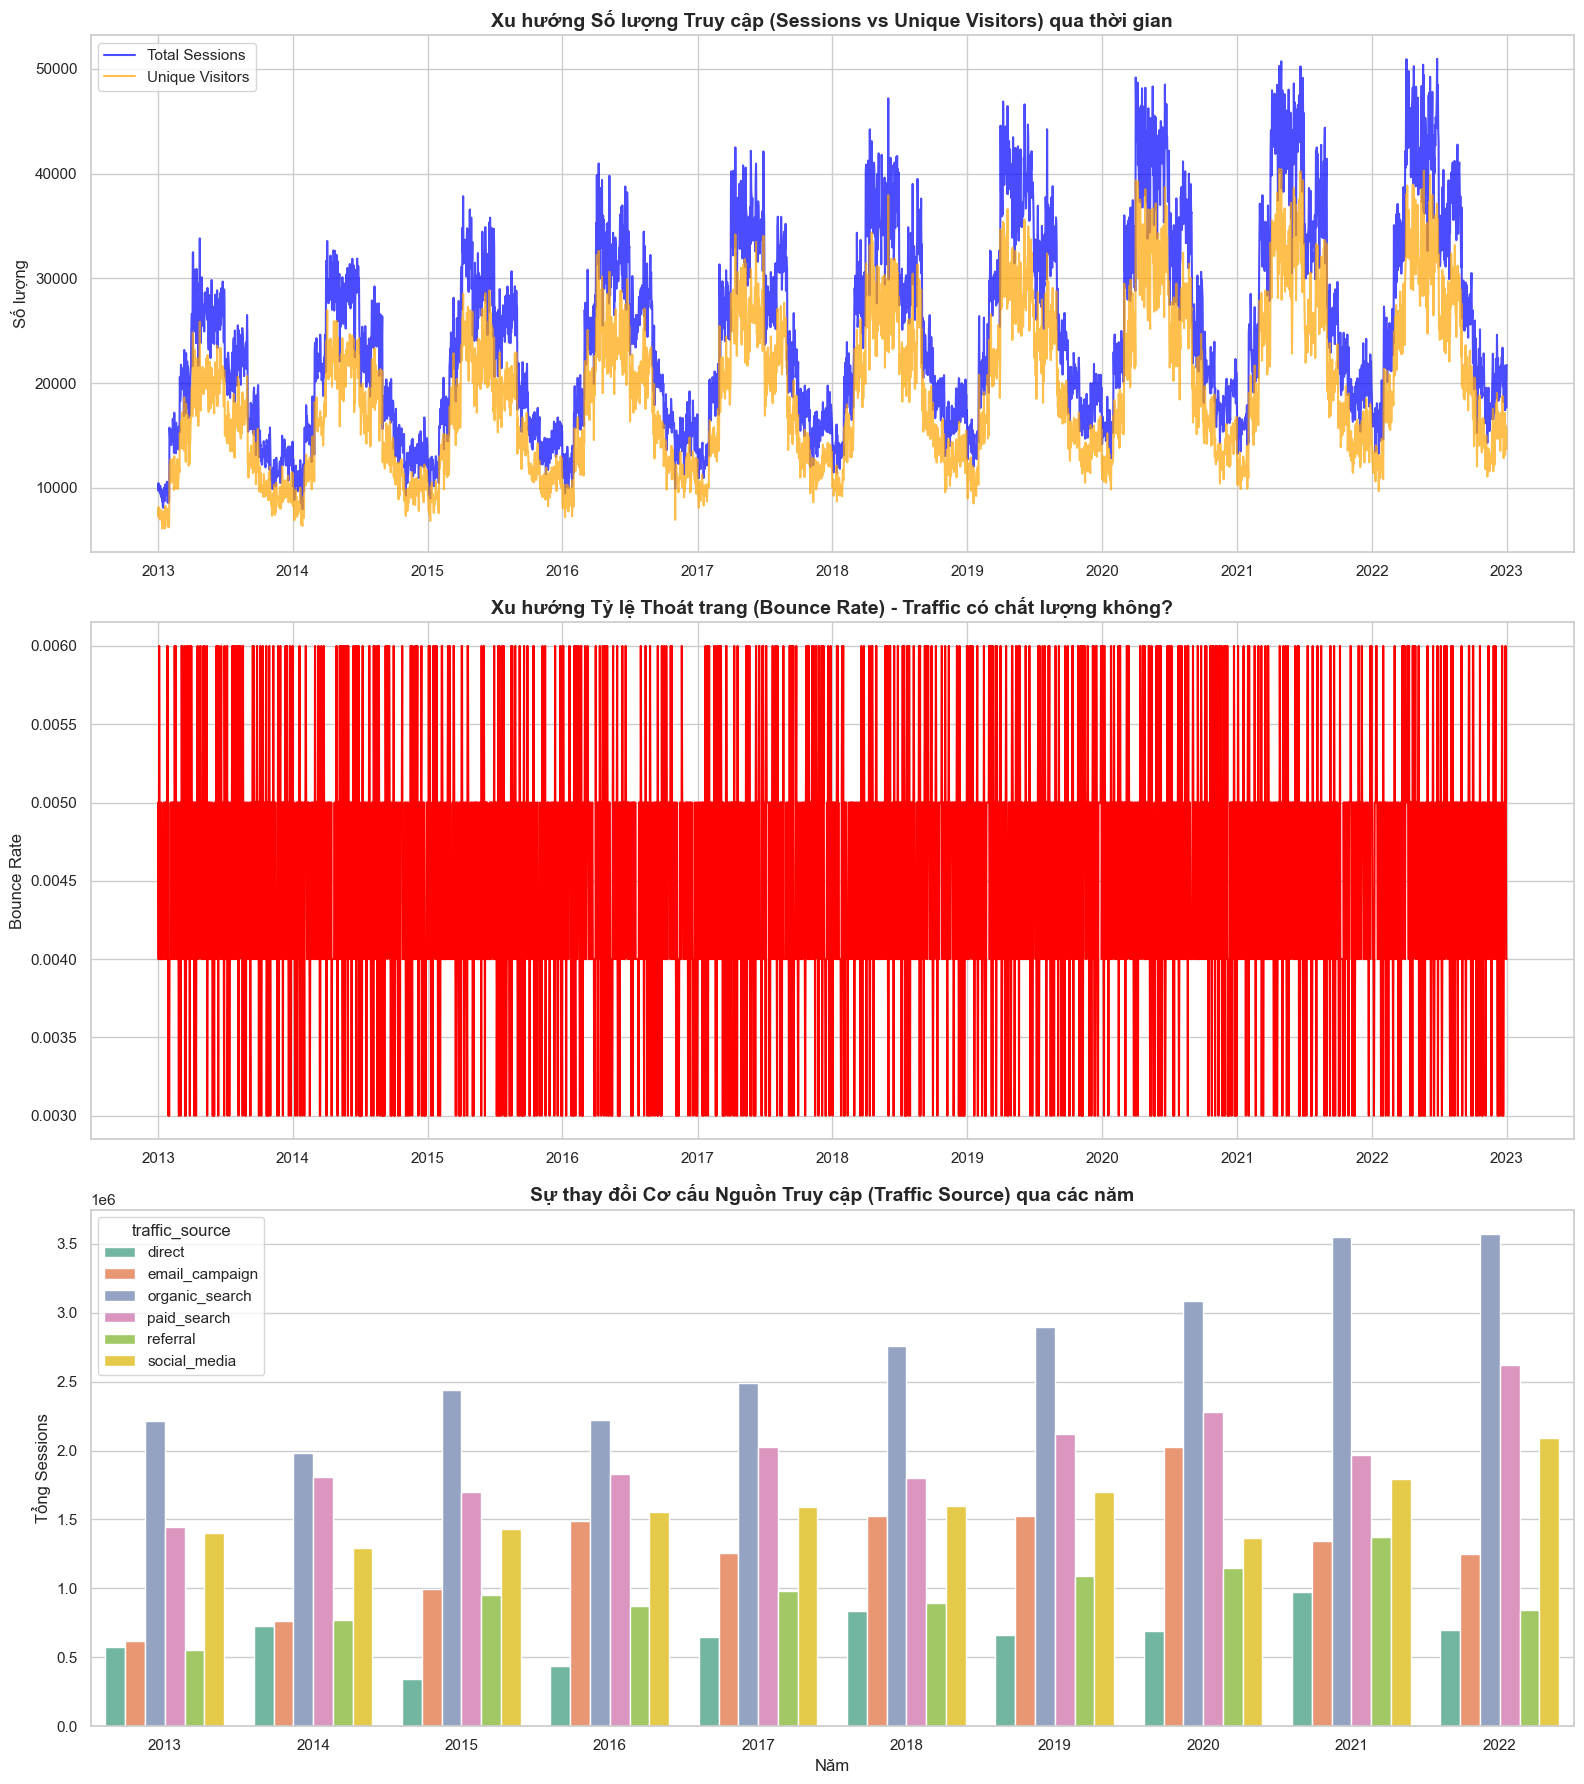

In [56]:
# 2. Tổng hợp dữ liệu theo NGÀY (Bỏ qua traffic_source để xem tổng quan)
daily_traffic = web_traffic.groupby('date').agg(
    total_sessions=('sessions', 'sum'),
    total_unique_visitors=('unique_visitors', 'sum'),
    total_page_views=('page_views', 'sum'),
    avg_bounce_rate=('bounce_rate', 'mean'), # Tỷ lệ thoát trang trung bình
    avg_duration=('avg_session_duration_sec', 'mean')
).reset_index()

# Thêm cột Year và Month để phân tích mùa vụ nếu cần
daily_traffic['year'] = daily_traffic['date'].dt.year
daily_traffic['month'] = daily_traffic['date'].dt.month

# 3. Trực quan hóa dữ liệu
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(3, 1, figsize=(16, 18))

# ==========================================
# Biểu đồ 1: Số lượng Traffic (Sessions & Visitors)
# ==========================================
sns.lineplot(data=daily_traffic, x='date', y='total_sessions', label='Total Sessions', ax=axes[0], color='blue', alpha=0.7)
sns.lineplot(data=daily_traffic, x='date', y='total_unique_visitors', label='Unique Visitors', ax=axes[0], color='orange', alpha=0.7)
axes[0].set_title('Xu hướng Số lượng Truy cập (Sessions vs Unique Visitors) qua thời gian', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Số lượng')
axes[0].set_xlabel('')
axes[0].legend()

# ==========================================
# Biểu đồ 2: Chất lượng Traffic (Bounce Rate)
# ==========================================
# Bounce rate càng thấp thì lượng traffic càng chất lượng
sns.lineplot(data=daily_traffic, x='date', y='avg_bounce_rate', ax=axes[1], color='red', linewidth=1.5)
axes[1].set_title('Xu hướng Tỷ lệ Thoát trang (Bounce Rate) - Traffic có chất lượng không?', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Bounce Rate')
axes[1].set_xlabel('')

# ==========================================
# Biểu đồ 3: Phân bổ Nguồn Traffic (Traffic Source)
# ==========================================
# Tổng hợp theo Năm và Nguồn để xem sự thay đổi chiến lược
source_yearly = web_traffic.groupby([web_traffic['date'].dt.year, 'traffic_source'])['sessions'].sum().reset_index()
sns.barplot(data=source_yearly, x='date', y='sessions', hue='traffic_source', ax=axes[2], palette='Set2')
axes[2].set_title('Sự thay đổi Cơ cấu Nguồn Truy cập (Traffic Source) qua các năm', fontsize=14, fontweight='bold')
axes[2].set_ylabel('Tổng Sessions')
axes[2].set_xlabel('Năm')

plt.tight_layout()
plt.show()

Khác với `reviews` và `inventory`, `web_traffic` lại cho ta thấy tính chu kỳ ở cột **session**, điều này có thể giúp ích cho mô hình học tốt hơn khi biết được số lượng truy cập vào web. Ngoài ra do dữ liệu từ **session** tính chu kỳ lặp lại khá đều và đang có xu hướng đi lên. Điều này giúp chúng tôi có thể xây dựng thêm một mô hình dự đoán **session** để làm dữ liệu tương lai cho mô hình dự báo. Đó có thể là một nguồn dữ liệu tốt cho mô hình

In [57]:
# 2. Tổng hợp Web Traffic theo ngày (Bỏ qua chia nhỏ theo nguồn)
# Chúng ta chỉ giữ lại total_sessions vì nó là biến đại diện tốt nhất
df_traffic_daily = web_traffic.groupby('date').agg(
    total_sessions=('sessions', 'sum')
).reset_index()

# 3. Merge vào bảng df_final
df_final = pd.merge(df_final, df_traffic_daily, on='date', how='left')

# 4. Xử lý giá trị thiếu (NaN)
# Những ngày không có dữ liệu traffic trong quá khứ thường là do lỗi ghi nhận,
# ta có thể fill bằng 0 hoặc dùng nội suy (interpolation). Ở đây fill 0 là an toàn nhất.
df_final['total_sessions'] = df_final['total_sessions'].fillna(0)

print("Đã merge Web Traffic và tạo các cột Lag thành công!")
df_final.tail()

Đã merge Web Traffic và tạo các cột Lag thành công!


,date,revenue,cogs,order_count,unique_customers,total_quantity,discount_pct,discount_fixed,is_global_promo,is_specific_promo,total_sessions
3828,2022-12-27,2100553.66,2184872.24,108,107,599,20.0,0.0,1.0,0.0,17416.0
3829,2022-12-28,3448729.20,3513621.00,164,163,901,20.0,0.0,1.0,0.0,21071.0
3830,2022-12-29,3083944.33,3170787.10,143,143,684,20.0,0.0,1.0,0.0,20884.0
3831,2022-12-30,2884668.76,3022292.15,106,106,502,20.0,0.0,1.0,0.0,17679.0
3832,2022-12-31,2383037.48,2279288.13,74,74,391,20.0,0.0,1.0,0.0,21743.0


## 4. Tổng kết
Sau khi đã tập hợp lại toàn bộ dữ liệu, thông tin có tính quy luật ảnh hưởng đến `revenue`, bộ dữ liệu này sẽ được tiếp tục qua một bước nữa là **features engineering** để lọc thêm một lần nữa, ngoài ra có thể tạo thêm cá biến từ quá khứ để dự báo cho tương lai. Cuối cùng, phần này sẽ kiểm tra lại toàn bộ dữ liệu một lượt để chắc chắn dữ liệu đã chính xác

In [58]:
df_final.info()

<class 'pandas.DataFrame'>
RangeIndex: 3833 entries, 0 to 3832
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   date               3833 non-null   datetime64[us]
 1   revenue            3833 non-null   float64       
 2   cogs               3833 non-null   float64       
 3   order_count        3833 non-null   int64         
 4   unique_customers   3833 non-null   int64         
 5   total_quantity     3833 non-null   int32         
 6   discount_pct       3833 non-null   float64       
 7   discount_fixed     3833 non-null   float64       
 8   is_global_promo    3833 non-null   float64       
 9   is_specific_promo  3833 non-null   float64       
 10  total_sessions     3833 non-null   float64       
dtypes: datetime64[us](1), float64(7), int32(1), int64(2)
memory usage: 314.6 KB


In [59]:
df_final.isnull().sum().sum()

np.int64(0)

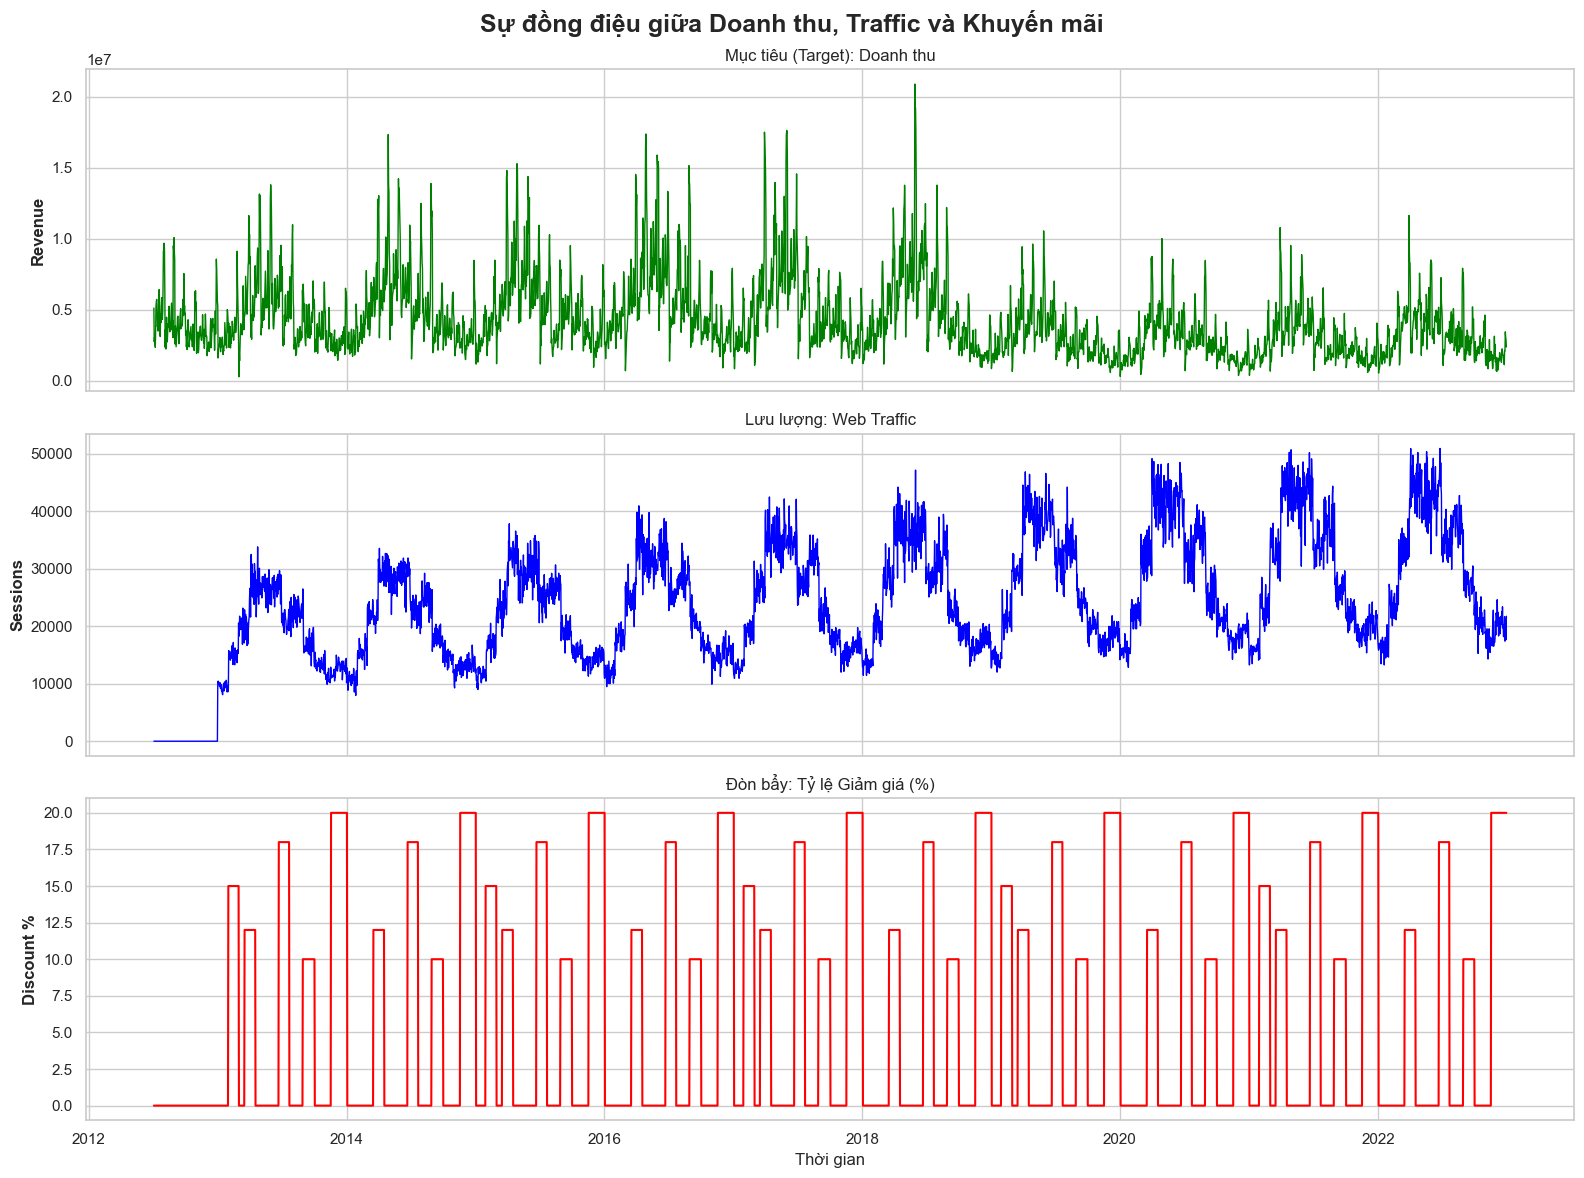

In [60]:
# Thiết lập style
sns.set_theme(style="whitegrid")

# ==========================================
# 1. BIỂU ĐỒ ĐỒNG BỘ THỜI GIAN (3 Tầng)
# ==========================================
fig, axes = plt.subplots(3, 1, figsize=(16, 12), sharex=True)
fig.suptitle('Sự đồng điệu giữa Doanh thu, Traffic và Khuyến mãi', fontsize=18, fontweight='bold', y=0.98)

# Tầng 1: Revenue
sns.lineplot(data=df_final, x='date', y='revenue', ax=axes[0], color='green', linewidth=1)
axes[0].set_ylabel('Revenue', fontweight='bold')
axes[0].set_title('Mục tiêu (Target): Doanh thu')

# Tầng 2: Total Sessions
sns.lineplot(data=df_final, x='date', y='total_sessions', ax=axes[1], color='blue', linewidth=1)
axes[1].set_ylabel('Sessions', fontweight='bold')
axes[1].set_title('Lưu lượng: Web Traffic')

# Tầng 3: Discount Pct
sns.lineplot(data=df_final, x='date', y='discount_pct', ax=axes[2], color='red', linewidth=1.5)
axes[2].set_ylabel('Discount %', fontweight='bold')
axes[2].set_title('Đòn bẩy: Tỷ lệ Giảm giá (%)')
axes[2].set_xlabel('Thời gian')

plt.tight_layout()
plt.show()

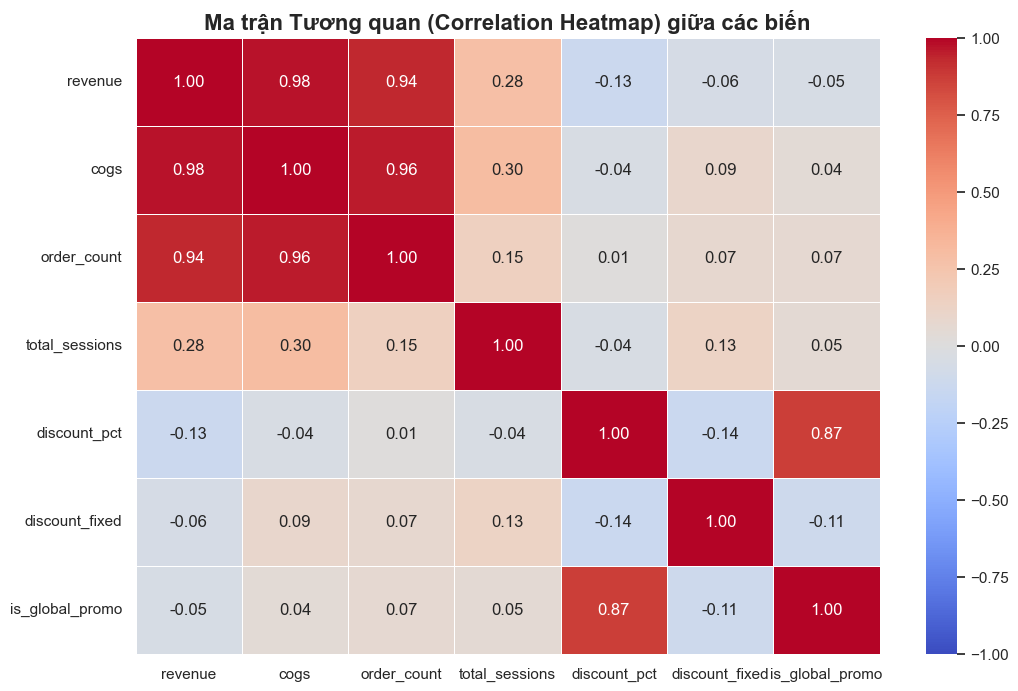

In [61]:
plt.figure(figsize=(12, 8))
# Bỏ cột date đi để tính tương quan các biến số học
corr_cols = ['revenue', 'cogs', 'order_count', 'total_sessions', 'discount_pct', 'discount_fixed', 'is_global_promo']
corr_matrix = df_final[corr_cols].corr()

# Vẽ Heatmap
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5, vmin=-1, vmax=1)
plt.title('Ma trận Tương quan (Correlation Heatmap) giữa các biến', fontsize=16, fontweight='bold')
plt.show()

C:\Users\YOGA\AppData\Local\Temp\ipykernel_2092\1625526937.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


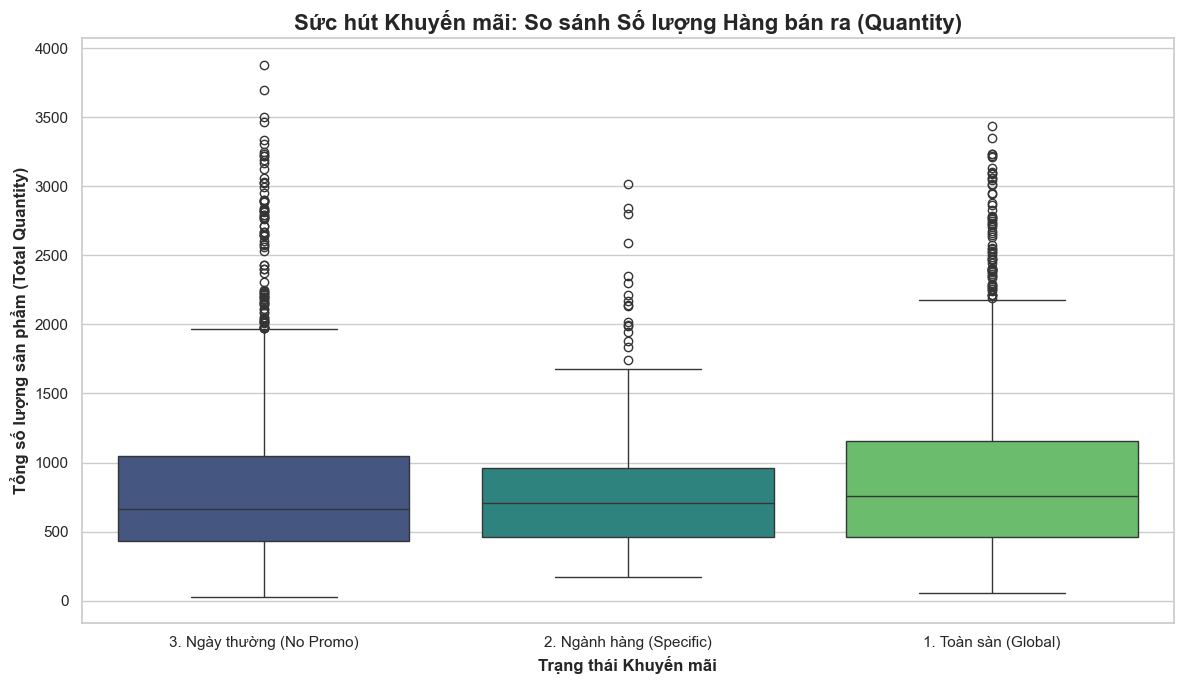

In [62]:
# Thiết lập style
sns.set_theme(style="whitegrid")

# 1. Tạo cột phân loại trạng thái khuyến mãi (nếu chưa có)
def categorize_promo(row):
    if row['is_global_promo'] == 1:
        return '1. Toàn sàn (Global)'
    elif row['is_specific_promo'] == 1:
        return '2. Ngành hàng (Specific)'
    else:
        return '3. Ngày thường (No Promo)'

df_final['promo_status'] = df_final.apply(categorize_promo, axis=1)

# 2. Vẽ Boxplot với trục Y là total_quantity
plt.figure(figsize=(12, 7))

# Sử dụng log scale nếu dữ liệu biến động quá cực đoan (như ngày Sale lớn gấp hàng chục lần ngày thường)
# plt.yscale('log') 

sns.boxplot(
    data=df_final, 
    x='promo_status', 
    y='total_quantity', 
    palette='viridis', 
    order=['3. Ngày thường (No Promo)', '2. Ngành hàng (Specific)', '1. Toàn sàn (Global)'],
    showfliers=True # Giữ lại các điểm ngoại lai (outliers) vì đó là các ngày Big Sale
)

plt.title('Sức hút Khuyến mãi: So sánh Số lượng Hàng bán ra (Quantity)', fontsize=16, fontweight='bold')
plt.xlabel('Trạng thái Khuyến mãi', fontweight='bold')
plt.ylabel('Tổng số lượng sản phẩm (Total Quantity)', fontweight='bold')

plt.tight_layout()
plt.show()

# (Tùy chọn) Xóa cột tạm
df_final.drop(columns=['promo_status'], inplace=True)

In [63]:
from src.save_data import save_to_processed
save_to_processed(df_final, 'sales_features.csv')

Đã lưu thành công tại: C:\Users\YOGA\Desktop\MyProjects\datathon\github\vimchanhxa-datathon\data\processed\sales_features.csv


---
**Kết luận:**

---
**Notebooks tiếp theo:** [03_EDA_.ipynb](03_EDA_.ipynb) - Khám phá dữ liệu